In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
#Raw dataset
df = pd.read_csv('lyrics_raw.csv')

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 424 | Val: 53 | Test: 53


In [9]:
# Human annotation test set (50 songs)
human_annotation = pd.read_csv('human_annotation.csv')

print(f'Annotation set : {human_annotation.shape[0]} songs')
print(f'\nValence distribution (human labels):')
print(human_annotation['primary_valence'].value_counts().to_string())
human_annotation[['track_name', 'artist', 'primary_valence', 'dominant_emotion', 'notes']].head(5)

Annotation set : 50 songs

Valence distribution (human labels):
primary_valence
Positive           18
Mixed              17
Negative           10
Neutral-unclear     5


,track_name,artist,primary_valence,dominant_emotion,notes
0,Codeine Crazy,Future,Mixed,"pride/confidence, sadness/loss, resilience/def...",addiction framed positively (luxury + success)...
1,Shake That,Eminem,Positive,"joy/celebration, pride/confidence",party/club context; explicit language may bias...
2,Location (feat. Burna Boy),Dave,Positive,"pride/confidence, joy/celebration, love/affection",success narrative (“came a long way”) with sla...
3,Let Me Calm Down (feat. J. Cole),Nicki Minaj,Mixed,"sadness/loss, anger/aggression, love/affection",conflicting emotions in relationships; polarit...
4,KOD,J. Cole,Mixed,"pride/confidence, anger/aggression, sadness/loss",drug culture critique vs glorification; negati...


In [3]:
# Model 1 — General RoBERTa (baseline)
RoBERTa = pipeline(
    task="text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment"
)

# Model 2 — Emotion/domain-specific
RoBERTa_emotion = pipeline(
    task="text-classification",
    model="j-hartmann/emotion-english-distilroberta-base"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# sample on how the model will work
label_map = {
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive"
}

lyric = "the fact that I was at O'Block and I was unstoppable"

result1 = RoBERTa(lyric, truncation=True, max_length=512)
result2 = RoBERTa_emotion(lyric, truncation=True, max_length=512)

print("Model 1:", label_map[result1[0]['label']], f"(score: {result1[0]['score']:.3f})")
print("Model 2:", result2[0]['label'], f"(score: {result2[0]['score']:.3f})")

Model 1: Positive (score: 0.729)
Model 2: surprise (score: 0.420)


In [17]:
# Error Analysis - compare human annotation to RoBERTa
emotion_to_valence = {
    'joy'     : 'Positive',
    'surprise': 'Positive',
    'neutral' : 'Neutral',
    'sadness' : 'Negative',
    'anger'   : 'Negative',
    'fear'    : 'Negative',
    'disgust' : 'Negative'
}

def run_model1(text):
    result = RoBERTa(text, truncation=True, max_length=512)
    raw_label = result[0]['label']
    return label_map_m1[raw_label], result[0]['score']

def run_model2(text):
    result = RoBERTa_emotion(text, truncation=True, max_length=512)
    emotion = result[0]['label']
    valence = emotion_to_valence.get(emotion, 'Neutral')
    return emotion, valence, result[0]['score']

print('Running Model 1 predictions...')
m1_results = human_annotation['raw_lyrics'].apply(run_model1)
human_annotation['m1_valence'] = m1_results.apply(lambda x: x[0])
human_annotation['m1_score']   = m1_results.apply(lambda x: x[1])

print('Running Model 2 predictions...')
m2_results = human_annotation['raw_lyrics'].apply(run_model2)
human_annotation['m2_emotion'] = m2_results.apply(lambda x: x[0])
human_annotation['m2_valence'] = m2_results.apply(lambda x: x[1])
human_annotation['m2_score']   = m2_results.apply(lambda x: x[2])

human_annotation[['track_name', 'primary_valence', 'm1_valence', 'm2_emotion', 'm2_valence']].head(10)


Running Model 1 predictions...
Running Model 2 predictions...


,track_name,primary_valence,m1_valence,m2_emotion,m2_valence
0,Codeine Crazy,Mixed,Neutral,neutral,Neutral
1,Shake That,Positive,Negative,disgust,Negative
2,Location (feat. Burna Boy),Positive,Neutral,neutral,Neutral
3,Let Me Calm Down (feat. J. Cole),Mixed,Neutral,anger,Negative
4,KOD,Mixed,Negative,disgust,Negative
5,Funky Friday,Positive,Neutral,surprise,Positive
6,Pray For Me,Negative,Neutral,fear,Negative
7,Mona Lisa (feat. Kendrick Lamar),Negative,Neutral,fear,Negative
8,Space Bound,Negative,Negative,fear,Negative
9,Home Alone (with J. Cole),Mixed,Neutral,anger,Negative


In [21]:
# Binarise: Positive → 1, everything else → 0
# (Mixed and Neutral-unclear are treated as non-positive for strict comparison)
def binarise(label):
    if label == 'Positive':
        return 'Positive'
    else:
        return 'Negative'  # covers Negative, Mixed, Neutral-unclear

human_annotation['human_binary'] = human_annotation['primary_valence'].apply(binarise)
human_annotation['m1_binary'] = human_annotation['m1_valence'].apply(binarise)
human_annotation['m2_binary'] = human_annotation['m2_valence'].apply(binarise)

# Error flags
human_annotation['m1_error'] = human_annotation['human_binary'] != human_annotation['m1_binary']
human_annotation['m2_error'] = human_annotation['human_binary'] != human_annotation['m2_binary']
human_annotation['both_error'] = human_annotation['m1_error'] & human_annotation['m2_error']

print(f'Model 1 (RoBERTa) errors : {human_annotation["m1_error"].sum()}/{len(human_annotation)}')
print(f'Model 2 errors (RoBERTa Emotion) : {human_annotation["m2_error"].sum()}/{len(human_annotation)}')
print(f'Both wrong     : {human_annotation["both_error"].sum()}/{len(human_annotation)}')

Model 1 (RoBERTa) errors : 19/50
Model 2 errors (RoBERTa Emotion) : 18/50
Both wrong     : 16/50


In [27]:
#evaluation
print('=' * 50)
print('MODEL 1 — cardiffnlp/twitter-roberta (Base RoBERTa)')
print('=' * 50)
print(classification_report(human_annotation['human_binary'], human_annotation['m1_binary'], target_names=['Negative','Positive']))

print('=' * 50)
print('MODEL 2 — j-hartmann/emotion-distilroberta (RoBERTa emotion)')
print('=' * 50)
print(classification_report(human_annotation['human_binary'], human_annotation['m2_binary'], target_names=['Negative','Positive']))

MODEL 1 — cardiffnlp/twitter-roberta (Base RoBERTa)
              precision    recall  f1-score   support

    Negative       0.63      0.97      0.77        32
    Positive       0.00      0.00      0.00        18

    accuracy                           0.62        50
   macro avg       0.32      0.48      0.38        50
weighted avg       0.40      0.62      0.49        50

MODEL 2 — j-hartmann/emotion-distilroberta (RoBERTa emotion)
              precision    recall  f1-score   support

    Negative       0.66      0.91      0.76        32
    Positive       0.50      0.17      0.25        18

    accuracy                           0.64        50
   macro avg       0.58      0.54      0.51        50
weighted avg       0.60      0.64      0.58        50



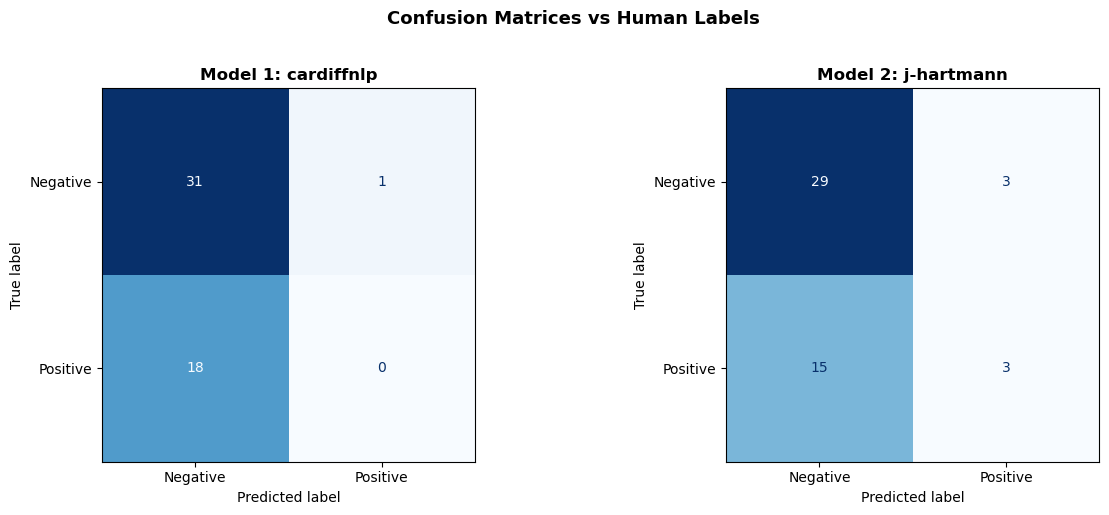

In [ ]:
#confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(
    axes,
    ['m1_binary', 'm2_binary'],
    ['Model 1: cardiffnlp', 'Model 2: j-hartmann']
):
    cm = confusion_matrix(human_annotation['human_binary'], human_annotation[col], labels=['Negative','Positive'])
    ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices vs Human Labels', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()